# Predictive Weight Optimisation for Men's March Madness Brackets

**Authors:** Bryce Clement, Christian Rutherford, Devon Diaco
**Course:** MAT-210, Davidson College, Spring 2026

This notebook walks through the full project end-to-end. Every result and
figure below is loaded from the on-disk artefacts produced by the scripts
in `src/`, so the notebook is cheap to re-run and stays consistent with
whatever the latest pipeline produced.

If any artefact below is missing, run the corresponding command:

| Artefact | Producer |
|---|---|
| `data/raw/kenpom_*.csv` | `python src/scrape_kenpom.py` |
| `data/raw/schedules/*.csv` | `python src/scrape_schedules.py` |
| `data/raw/fourfactors_*.csv` | `python src/scrape_fourfactors.py` |
| `data/processed/momentum_by_season.csv` | `python src/momentum.py` |
| `data/processed/matchups.csv` | `python src/build_features.py` |
| `models/*.joblib`, `models/cv_summary.json` | `python src/train_models.py` |
| `data/processed/round_importance_*.csv` | `python src/feature_importance.py` |
| `data/processed/backtest_results.csv` | `python src/backtest.py` |
| `data/processed/2026_*.csv` | `python src/run_2026.py` |
| `figures/*.png` | `python src/make_figures.py` |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIG = ROOT / 'figures'

pd.options.display.float_format = '{:,.3f}'.format
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

## 1. Data layer

We pull three primary sources from KenPom (paid login) and one from
ESPN (Wayback Machine):

* **Season-end ratings** for every team-season 2010–2026 (offensive /
  defensive efficiency, tempo, luck, strength of schedule, seed).
* **Per-game schedules** for every tournament team-season — used to
  build the decay-weighted late-season momentum signal.
* **Four Factors** (eFG%, TO%, OR%, FTRate, both sides) — the proposal
  named *Effective Field Goal Percentage* explicitly so we wire eFG%
  into the feature set.
* **ESPN "who picked whom"** public-pick percentages, 2019 only, used
  as a synthetic seed×round prior for any other year (the only year
  that was reachable via the Wayback Machine).

In [2]:
import os
season_years = sorted({int(p.stem.split('_')[1]) for p in RAW.glob('kenpom_*.csv')})
n_schedules = len(list((RAW / 'schedules').glob('*.csv')))
n_fourfactors = len(list(RAW.glob('fourfactors_*.csv')))
espn = pd.read_csv(RAW / 'espn_picks_all.csv')

print(f'KenPom season-end files: {len(season_years)} seasons '
      f'({min(season_years)}-{max(season_years)})')
print(f'KenPom per-game schedules:   {n_schedules} team-seasons')
print(f'KenPom Four Factors files:   {n_fourfactors} seasons')
print(f'ESPN public picks:           {len(espn)} rows, year(s) {sorted(espn.Year.unique())}')

KenPom season-end files: 17 seasons (2010-2026)
KenPom per-game schedules:   1023 team-seasons
KenPom Four Factors files:   17 seasons
ESPN public picks:           384 rows, year(s) [2019]


### 1.1 Matchup feature matrix

`build_features.py` joins all of the above into a single matchup matrix.
Each tournament game appears as **two rows** (mirrored Team A / Team B
framing) so the dataset is balanced. Each row is a 11-vector of *Team A
minus Team B* feature deltas: 10 KenPom statistics plus seed differential.

In [3]:
matchups = pd.read_csv(PROC / 'matchups.csv')
print(f'Matchup rows (with mirrors): {len(matchups)}')
print(f'Label balance: {matchups.label.mean():.3f}')
print(f'Seasons covered: {matchups.Season.min()}-{matchups.Season.max()}')
print(f'Round breakdown:')
print(matchups.Round.value_counts().to_frame('rows'))

Matchup rows (with mirrors): 2014
Label balance: 0.500
Seasons covered: 2010-2026
Round breakdown:
              rows
Round             
First Round   1022
Second Round   512
Sweet 16       256
Elite 8        128
Final Four      64
Championship    32


In [4]:
delta_cols = [c for c in matchups.columns if c.startswith('d_')]
print('Feature deltas (model input):')
print(delta_cols)
matchups[['Season', 'Round', 'TeamA', 'TeamB'] + delta_cols].head(4)

Feature deltas (model input):
['d_AdjEM', 'd_AdjO', 'd_AdjD', 'd_AdjT', 'd_Luck', 'd_SOS-AdjEM', 'd_NCSOS-AdjEM', 'd_Momentum', 'd_OffEFG', 'd_DefEFG', 'd_Seed']


,Season,Round,TeamA,TeamB,d_AdjEM,d_AdjO,d_AdjD,d_AdjT,d_Luck,d_SOS-AdjEM,d_NCSOS-AdjEM,d_Momentum,d_OffEFG,d_DefEFG,d_Seed
0,2010,First Round,Kentucky,East Tennessee St.,24.070,14.000,-10.100,1.500,0.064,8.320,-10.250,-5.335,5.400,-5.500,-15
1,2010,First Round,East Tennessee St.,Kentucky,-24.070,-14.000,10.100,-1.500,-0.064,-8.320,10.250,5.335,-5.400,5.500,15
2,2010,First Round,Wake Forest,Texas,-6.630,-6.800,-0.100,-2.800,0.081,1.500,0.500,7.507,-4.100,-1.100,1
3,2010,First Round,Texas,Wake Forest,6.630,6.800,0.100,2.800,-0.081,-1.500,-0.500,-7.507,4.100,1.100,-1


## 2. Decay-weighted momentum feature

The proposal asked for "a decay weight to late-season team performance
& conference tournament results." We build this by walking each
team-season's per-game KenPom schedule and computing for each game

$$
\text{eff\_em}_g = \frac{\text{PF}_g - \text{PA}_g}{\text{poss}_g}\cdot 100
                   + \text{AdjEM}_{\text{opp}(g)}
                   + \text{loc\_adj}_g
$$

(i.e. "what AdjEM did this team play at in this game, adjusted for the
opponent and home-court advantage"). We exclude NCAA tournament games
to avoid label leakage, then take a weighted average where the weights
are an exponential decay with `tau = 30 days` anchored on Selection
Sunday, multiplied by `1.5×` for conference-tournament games. Subtracting
the team's season-long AdjEM gives `MomentumDelta` — a trajectory
signal orthogonal to the season-end rating already in `d_AdjEM`.

In [5]:
mom = pd.read_csv(PROC / 'momentum_by_season.csv')
print(f'Total team-seasons with decay momentum: {len(mom)}')
print(f"Mean MomentumDelta (across all 2010-2026 tournament teams): "
      f"{mom['MomentumDelta'].mean():+.2f} pts/100 possessions")
print()
print('2026 tournament teams - top 8 by trajectory:')
display(mom[mom.Season == 2026]
        .sort_values('MomentumDelta', ascending=False)
        .head(8)[['Team', 'SeasonAdjEM', 'MomentumDecay', 'MomentumDelta', 'NGames']])
print('2026 tournament teams - bottom 5 by trajectory:')
display(mom[mom.Season == 2026]
        .sort_values('MomentumDelta')
        .head(5)[['Team', 'SeasonAdjEM', 'MomentumDecay', 'MomentumDelta', 'NGames']])

Total team-seasons with decay momentum: 1023
Mean MomentumDelta (across all 2010-2026 tournament teams): +9.12 pts/100 possessions

2026 tournament teams - top 8 by trajectory:


,Team,SeasonAdjEM,MomentumDecay,MomentumDelta,NGames
1014,UCF,14.970,34.168,19.198,32
991,Missouri,14.930,33.674,18.744,32
981,Kansas,24.150,42.008,17.858,33
1015,UCLA,21.190,38.218,17.028,34
1012,Texas Tech,24.460,41.089,16.629,32
996,Ohio St.,22.220,38.836,16.616,33
980,Iowa St.,32.000,48.145,16.145,34
1011,Texas A&M,18.690,33.860,15.170,32


2026 tournament teams - bottom 5 by trajectory:


,Team,SeasonAdjEM,MomentumDecay,MomentumDelta,NGames
988,Miami OH,8.640,7.469,-1.171,29
989,Michigan,39.700,38.914,-0.786,34
973,High Point,9.520,11.049,1.529,31
961,Arizona,38.060,40.067,2.007,34
959,Akron,11.940,14.185,2.245,32


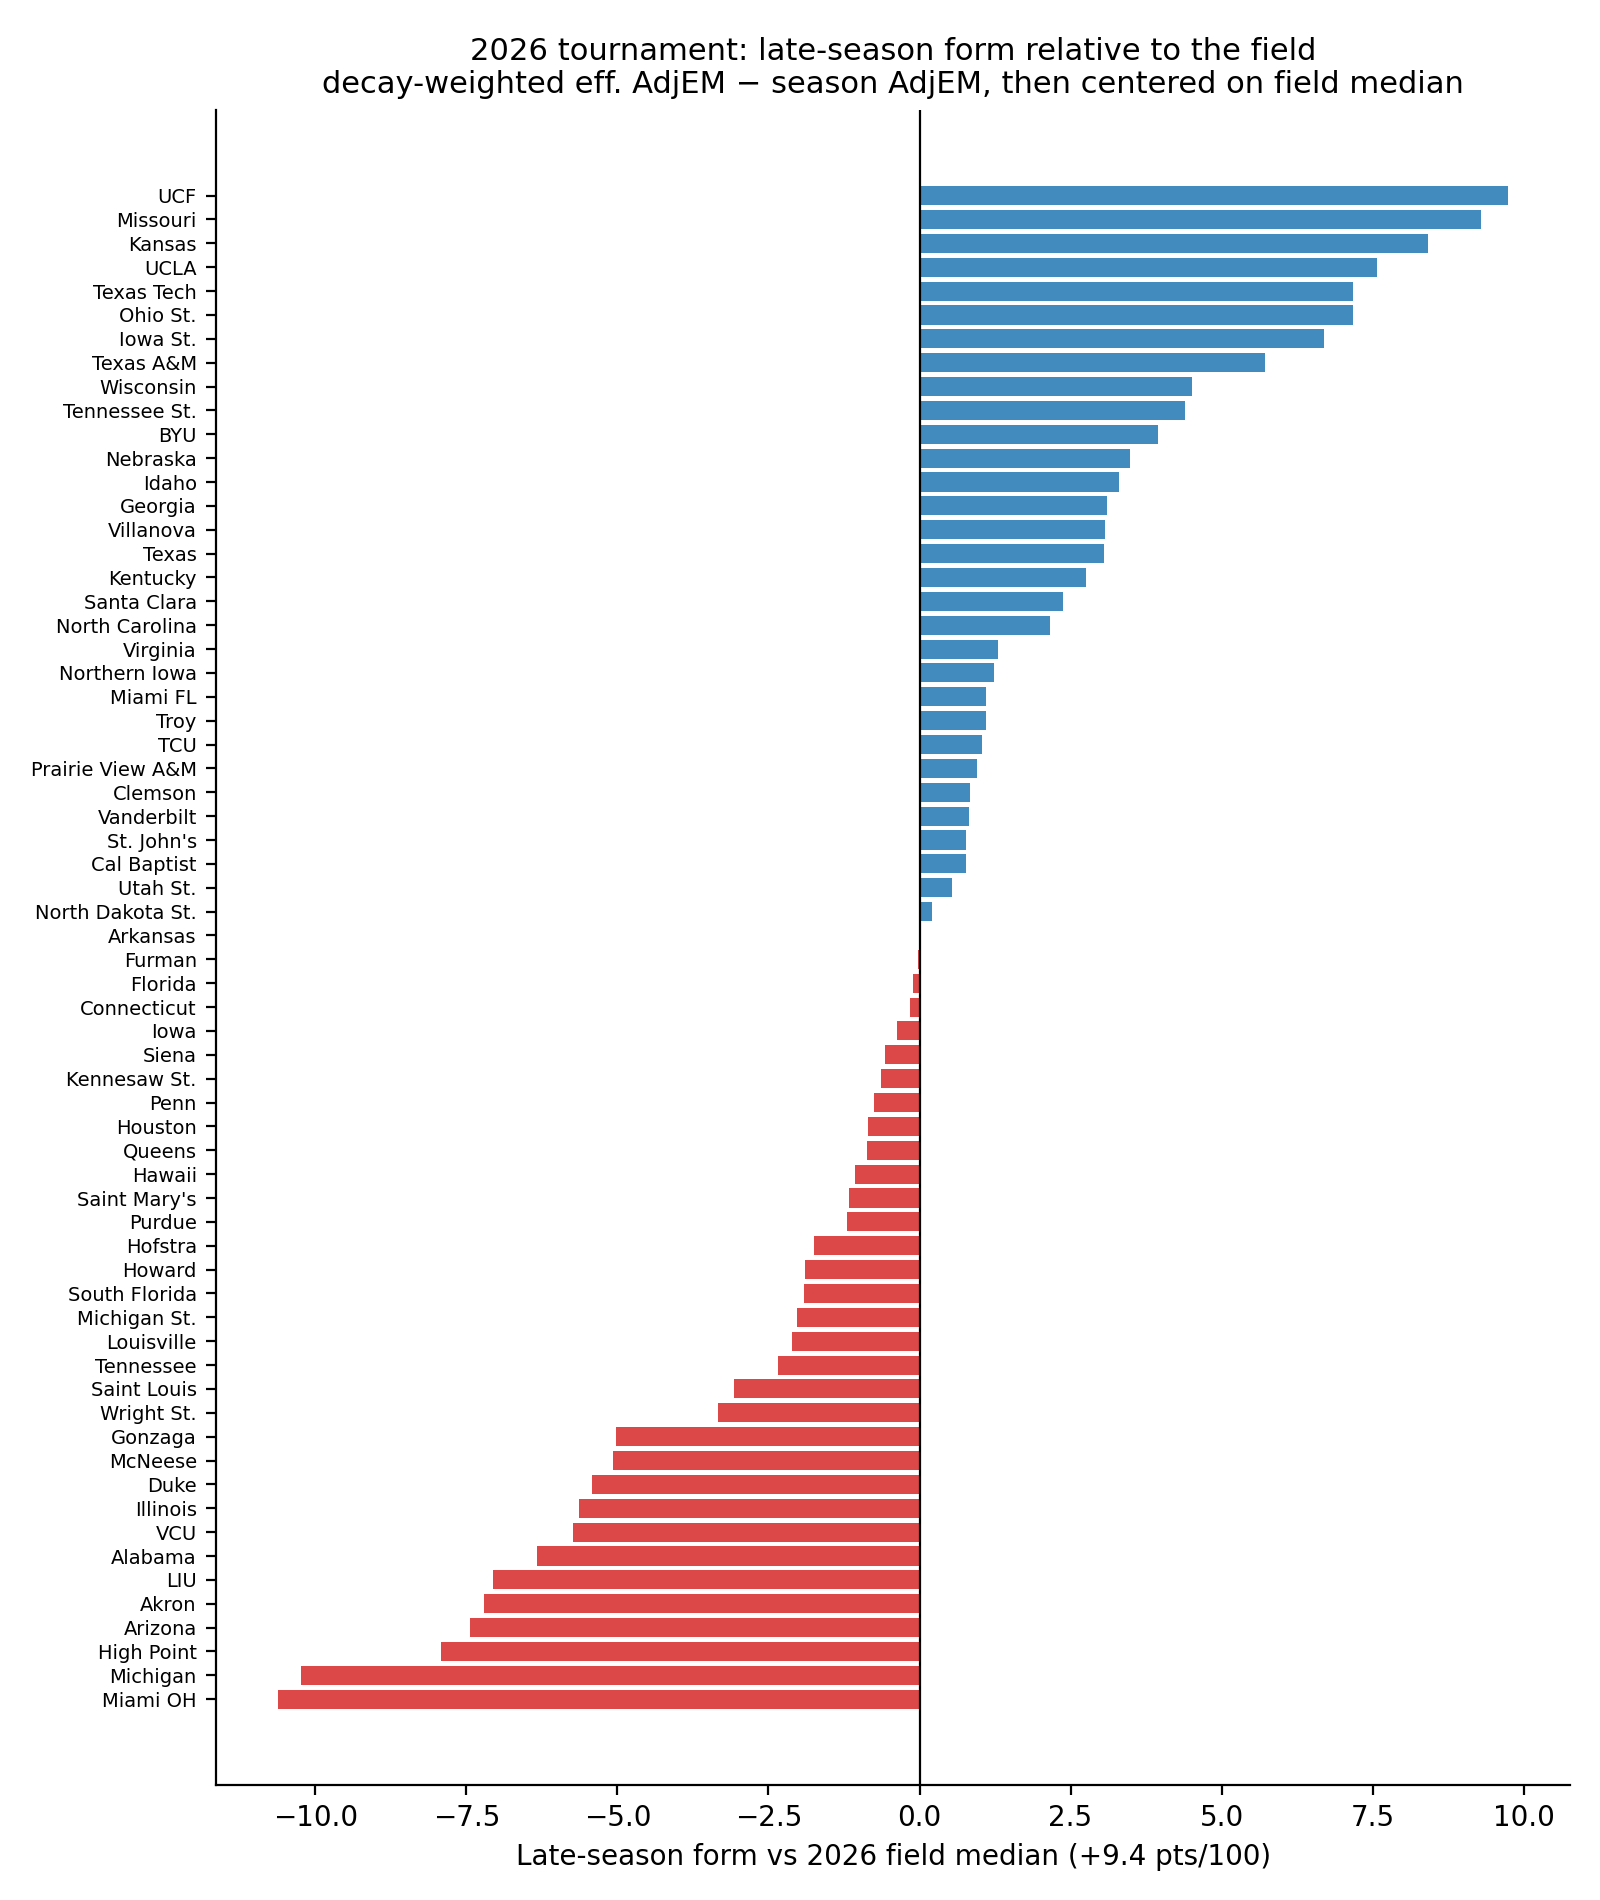

In [6]:
display(Image(filename=str(FIG / 'momentum_2026.png')))

## 3. Win-probability model

We fit six models in a leave-one-season-out (LOSO) cross-validation
loop — at each fold we hold out one tournament season, train on the
other 15, predict the held-out season. Metrics are aggregated across
folds so they directly mimic real-world usage (predict the next
tournament from past tournaments only).

**Models compared:**
1. Seed-only Logistic Regression (interpretable baseline)
2. **Full Logistic Regression** — all 11 deltas (primary model)
3. XGBoost
4. Random Forest
5. LightGBM
6. CatBoost

In [7]:
import json
cv = json.loads((MODELS / 'cv_summary.json').read_text())
cv_df = pd.DataFrame(cv).T
cv_df = cv_df.sort_values('log_loss_mean')
display(cv_df[['log_loss_mean', 'log_loss_std', 'brier_mean', 'acc_mean']])
print(f'Best model by log-loss: {cv_df.index[0]}')
print(f'(log-loss is the proper scoring rule: it rewards calibrated probabilities,')
print(f' which is what bracket simulation downstream needs.)')

,log_loss_mean,log_loss_std,brier_mean,acc_mean
full_LR,0.410,0.090,0.129,0.830
xgb,0.434,0.094,0.135,0.816
catboost,0.442,0.092,0.137,0.808
rf,0.471,0.060,0.153,0.783
lgbm,0.518,0.140,0.145,0.812
seed_only_LR,0.572,0.046,0.195,0.705


Best model by log-loss: full_LR
(log-loss is the proper scoring rule: it rewards calibrated probabilities,
 which is what bracket simulation downstream needs.)


### 3.1 Model calibration

A reliability diagram bins the LOSO out-of-fold predictions by
predicted probability and plots the empirical win rate inside each bin.
A perfectly-calibrated model lies on the diagonal — predicted P=0.7
should imply that the team actually wins 70% of the time.

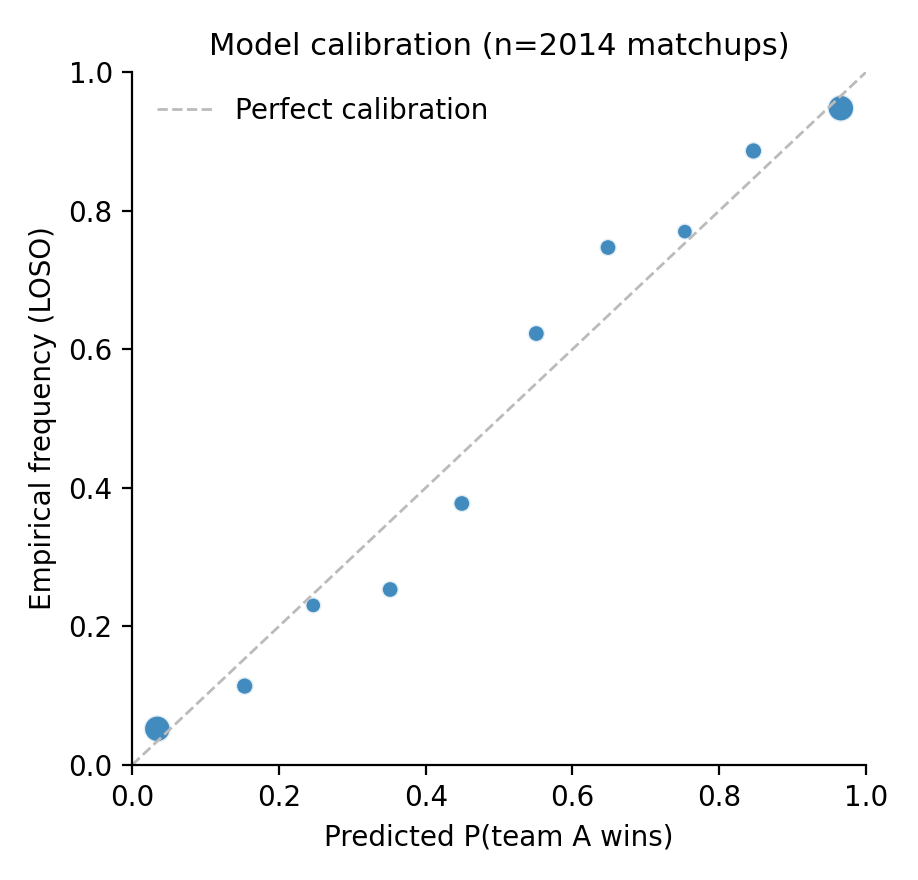

In [8]:
display(Image(filename=str(FIG / 'reliability.png')))

## 4. Round-specific feature importance

The proposal asked: "does 3-point shooting matter more in the Sweet 16
than in the Round of 64?" — a question about whether feature importance
*shifts* by round. We answer this two ways:

1. **Per-round logistic regression** (`round_importance_lr.csv`):
   train one LR per round, report standardised coefficients. Larger
   `|coef|` means the feature has more pull conditional on being in
   that round.
2. **Per-round permutation importance** (`round_importance_perm.csv`):
   for each (model, round, feature) we shuffle that one feature among
   the round's rows, score with the trained model, and measure the
   increase in log-loss. Averaged over 30 random shuffles for stability.

In [9]:
lr_imp = pd.read_csv(PROC / 'round_importance_lr.csv')
pivot = lr_imp.pivot(index='Feature', columns='Round', values='Coef')
pivot = pivot[[c for c in ['R64', 'R32', 'S16', 'E8', 'F4', 'NCG'] if c in pivot.columns]]
print('Standardised LR coefficients by round (sign matters: +ve favors Team A):')
display(pivot.round(2))

Standardised LR coefficients by round (sign matters: +ve favors Team A):


Round,R64,R32,S16,E8,F4,NCG
Feature,,,,,,
d_AdjD,-1.620,-1.350,-0.220,-0.390,-1.280,-0.400
d_AdjEM,1.790,1.700,0.920,1.240,1.520,1.110
d_AdjO,1.570,1.160,0.980,1.210,0.890,0.800
d_AdjT,-0.020,0.140,-0.230,-0.430,0.080,0.270
d_DefEFG,-0.020,0.300,-0.410,-0.310,0.420,0.020
d_Luck,1.030,0.790,1.240,0.800,0.920,1.030
d_Momentum,-0.450,-0.730,-1.100,-0.730,0.440,-0.130
d_NCSOS-AdjEM,-0.060,-0.070,0.110,0.130,0.030,-0.960
d_OffEFG,-0.050,0.230,-0.340,-0.850,0.360,0.100


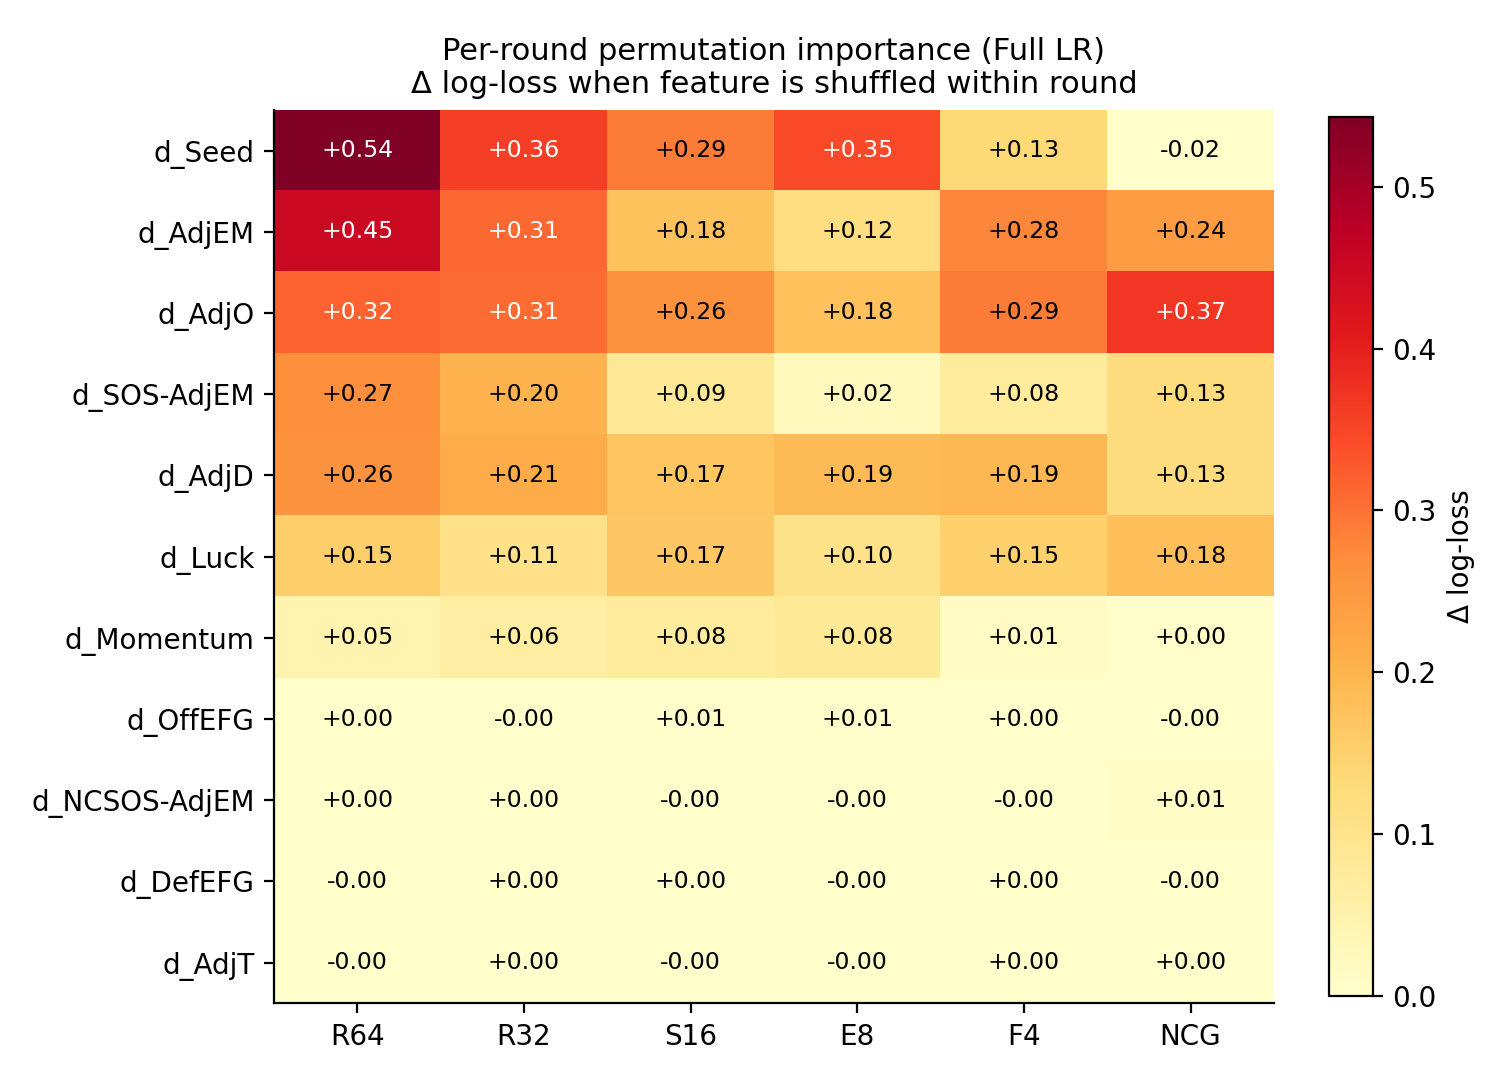

In [10]:
display(Image(filename=str(FIG / 'round_importance.png')))

**Reading the heatmap.** A few patterns jump out:

* `d_Seed` is dominant in R64 / R32 (chalk almost always wins early
  rounds) but its importance falls to ~0 in the Championship — by the
  Final Four, every remaining team is good enough that seed differential
  has stopped predicting much.
* `d_AdjO` (offensive efficiency) becomes the single most important
  feature in the Final Four and Championship. Defensive metrics matter
  most in the Elite 8.
* `d_Momentum` (decay-weighted late-season trajectory) carries the
  most signal in S16 — when teams that arrived hot keep winning.
* `d_OffEFG` and `d_DefEFG` overlap heavily with the AdjO/AdjD summary
  metrics and add comparatively little marginal log-loss reduction —
  but they do appear at the top in Final Four and Elite 8.

## 5. Monte Carlo bracket simulation

Given a per-matchup win probability function and a 64-team bracket, we
draw N = 10,000 simulated tournament outcomes by walking the bracket
node by node. Recording how often each team reaches each round gives
us a 64×7 reach-probability table. ESPN scoring (10 / 20 / 40 / 80 /
160 / 320 per correct pick R64→NCG) decomposes by linearity of
expectation:

$$
\mathbb{E}[\text{score}] = \sum_{\text{round } r} \text{pts}(r)
\cdot \mathbb{P}(\text{picked team reaches round } r)
$$

so the EV-maximising bracket is the closed-form *greedy* choice at each
game: pick the team with the higher reach probability for the *next*
round. No exponential bracket search is needed.

## 6. Historical backtest, 2010–2026

For each season we train a model on the *other* fifteen seasons and
score two strategies on that season's actual outcome:

* **`chalk_seed`** — pick the lower seed at every game (no model).
* **`chalk_model`** — pick the higher model-probability team at every
  game.

In [11]:
back = pd.read_csv(PROC / 'backtest_results.csv')
display(back.assign(diff=back.actual_model_score - back.actual_seed_score))
print()
print(f"Mean chalk-seed score:   {back.actual_seed_score.mean():,.1f}")
print(f"Mean chalk-model score:  {back.actual_model_score.mean():,.1f}")
print(f"Mean expected (model):   {back.expected_model_score.mean():,.1f}")
n_wins = int((back.actual_model_score > back.actual_seed_score).sum())
print(f"Years model > seed (actual): {n_wins} / {len(back)}")

,season,actual_seed_score,actual_model_score,expected_seed_score,expected_model_score,diff_actual,diff_expected,diff
0,2010,620,1050,838.790,"1,222.866",430,384.076,430
1,2011,570,660,757.740,"1,343.812",90,586.072,90
2,2012,720,1480,740.706,"1,292.670",760,551.964,760
3,2013,800,1680,673.884,"1,091.960",880,418.076,880
4,2014,680,1230,763.962,"1,036.838",550,272.876,550
5,2015,1050,1070,"1,213.278","1,509.058",20,295.780,20
6,2016,710,1420,757.508,"1,271.904",710,514.396,710
7,2017,980,740,838.610,"1,107.254",-240,268.644,-240
8,2018,650,1280,784.710,"1,305.034",630,520.324,630
9,2019,760,1700,851.536,"1,270.248",940,418.712,940



Mean chalk-seed score:   827.3
Mean chalk-model score:  1,255.3
Mean expected (model):   1,250.5
Years model > seed (actual): 13 / 15


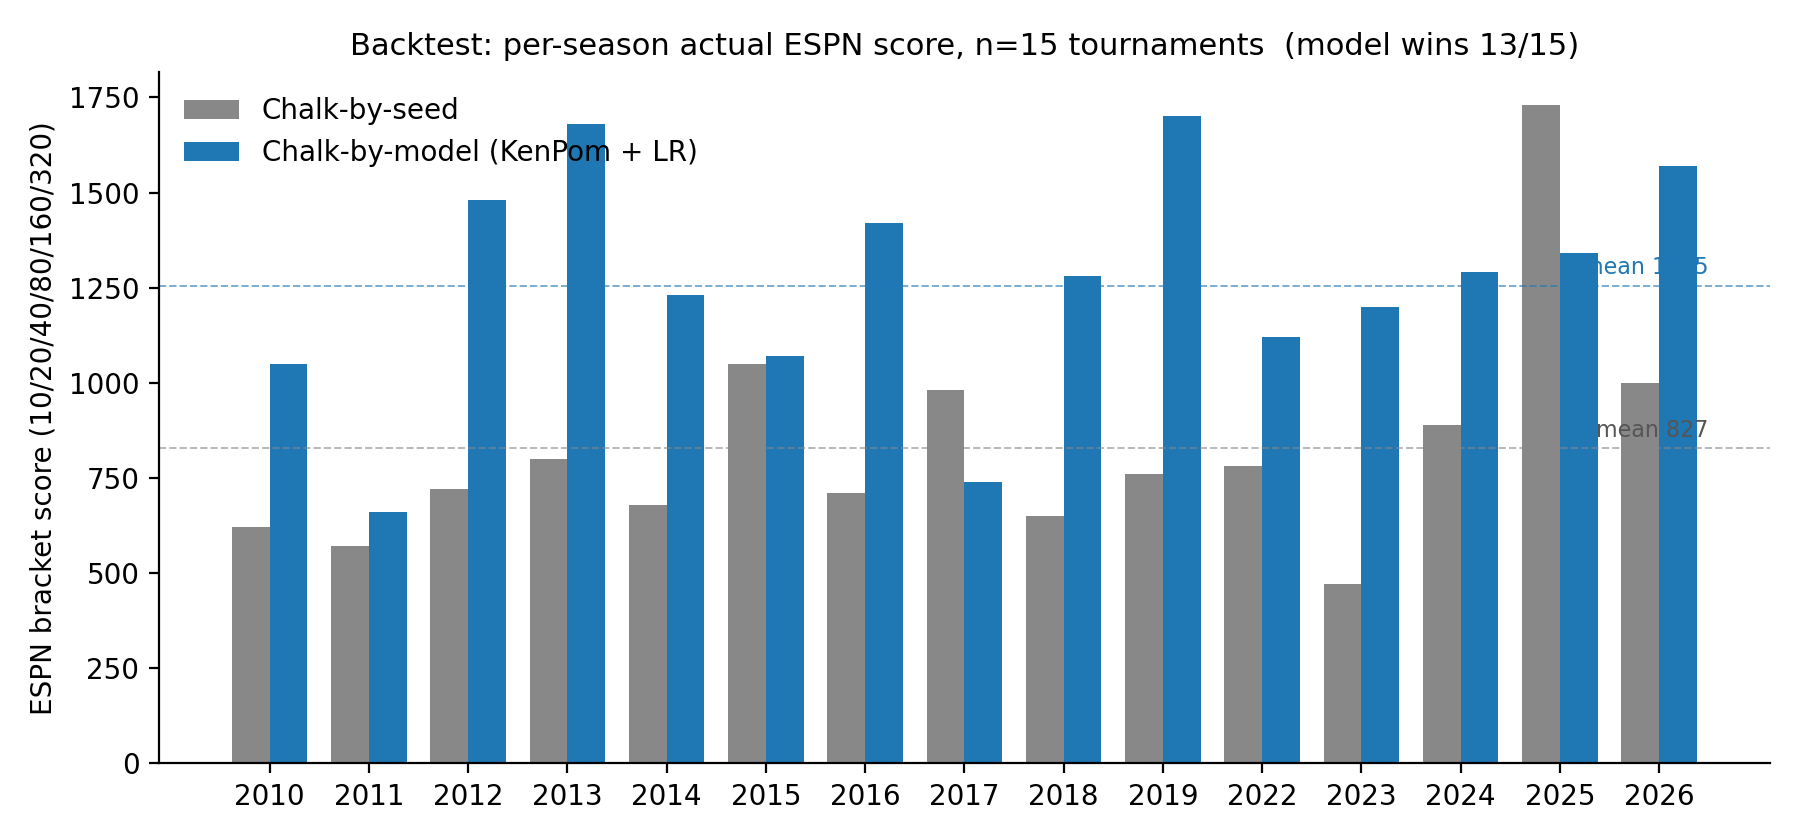

In [12]:
display(Image(filename=str(FIG / 'backtest.png')))

## 7. 2026 tournament — pre-tournament prediction & retrospective score

Before the 2026 tournament began, the model assigned the championship
probabilities below. The actual tournament concluded with **Michigan
defeating Connecticut 69–63**.

In [13]:
reach = pd.read_csv(PROC / '2026_reach_probs_model.csv', index_col=0)
top = reach.sort_values('p_Champ', ascending=False).head(10)
display(top[['p_R32', 'p_S16', 'p_E8', 'p_F4', 'p_NCG', 'p_Champ']].round(3))

,p_R32,p_S16,p_E8,p_F4,p_NCG,p_Champ
team,,,,,,
Michigan,1.000,0.999,0.978,0.970,0.846,0.672
Arizona,1.000,0.984,0.956,0.914,0.850,0.253
Duke,1.000,0.992,0.912,0.838,0.144,0.069
Illinois,0.999,0.948,0.565,0.434,0.059,0.003
Houston,1.000,0.931,0.425,0.296,0.039,0.001
Purdue,1.000,0.954,0.751,0.060,0.026,0.001
Vanderbilt,0.947,0.669,0.357,0.106,0.008,0.000
Connecticut,1.000,0.937,0.713,0.101,0.004,0.000
Florida,1.000,0.736,0.438,0.135,0.010,0.000


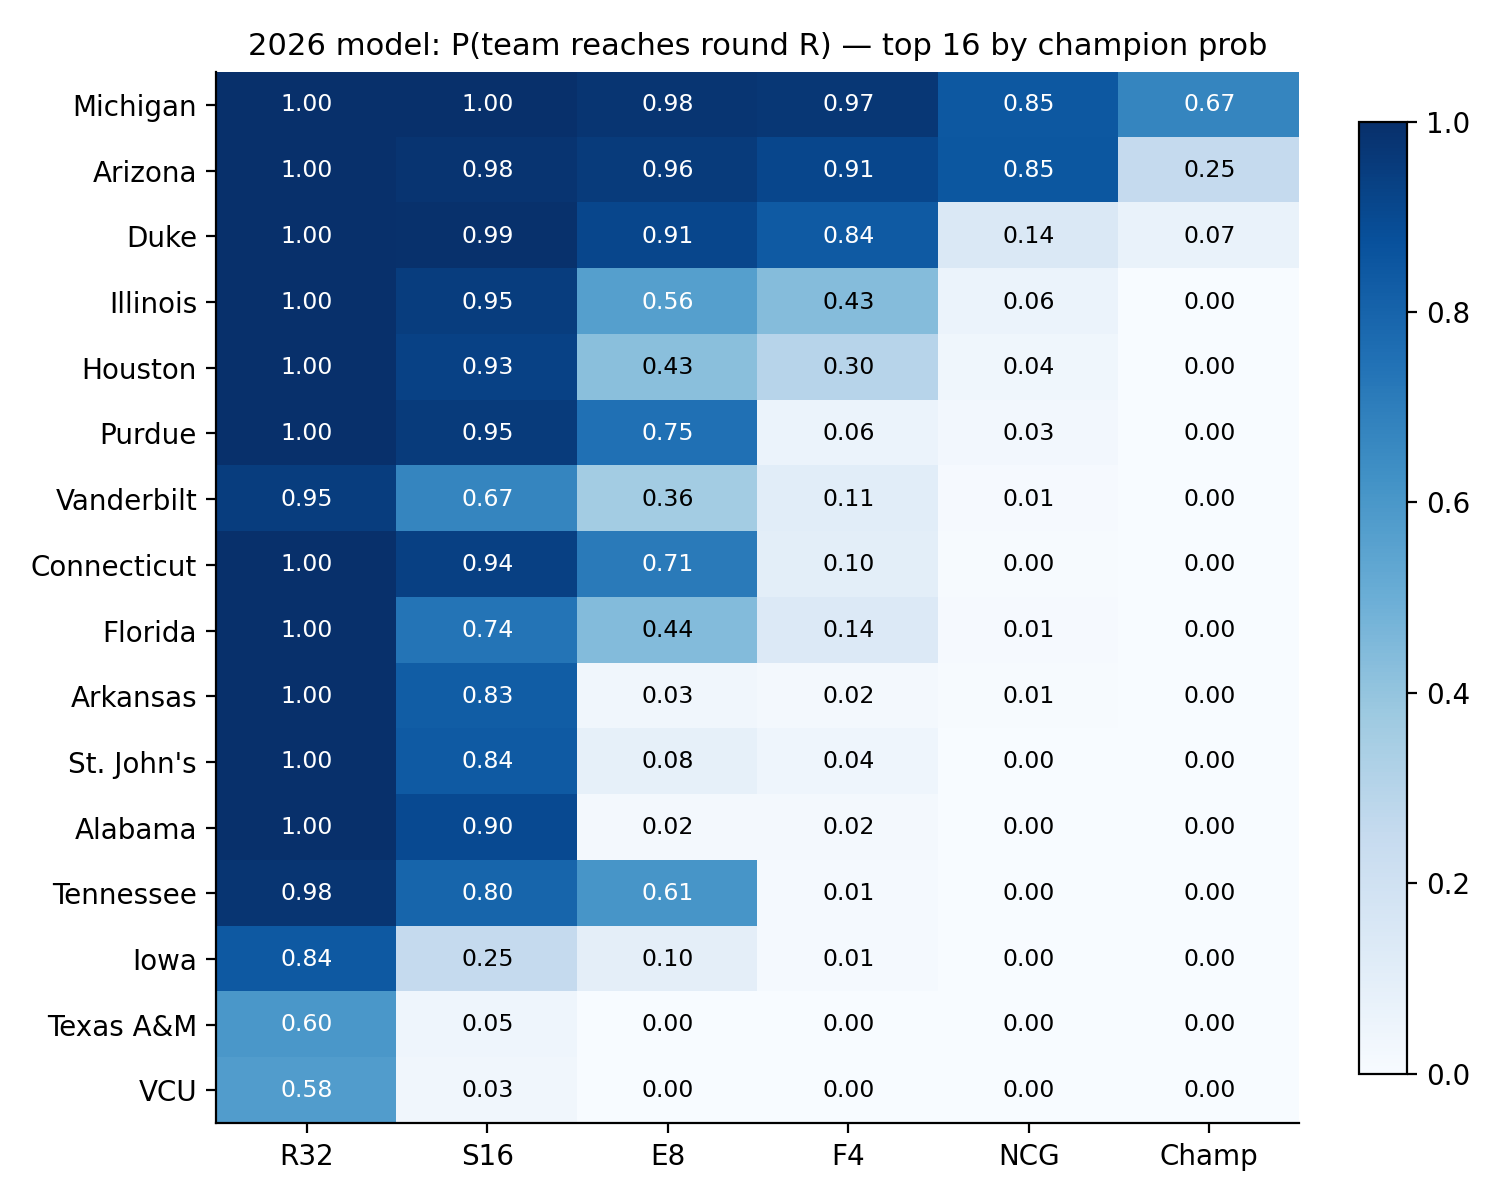

In [14]:
display(Image(filename=str(FIG / 'reach_2026.png')))

In [15]:
actual = pd.read_csv(PROC / '2026_actual_scores.csv')
print('2026 strategy scores against the actual outcome:')
display(actual)

2026 strategy scores against the actual outcome:


,strategy,actual_score,R64,R32,S16,E8,F4,NCG
0,chalk_seed,1000,240,240,200,160,160,0
1,chalk_model,1570,310,260,280,240,160,320
2,ev_max,1570,310,260,280,240,160,320


### 7.1 2026 strategy distribution

We re-simulate 10,000 outcome trajectories under the same trained
model and score each strategy on every simulated outcome. This shows
the *distribution* of plausible scores, not just the realised one.

In [16]:
dist = pd.read_csv(PROC / '2026_strategy_distribution.csv')
display(dist.round(1))

,strategy,mean_score,std_score,median_score,p10_score,p90_score
0,chalk_seed,"1,301.100",190.900,"1,290.000","1,060.000","1,590.000"
1,chalk_model,"1,528.500",221.800,"1,600.000","1,210.000","1,780.000"
2,ev_max,"1,528.500",221.800,"1,600.000","1,210.000","1,780.000"


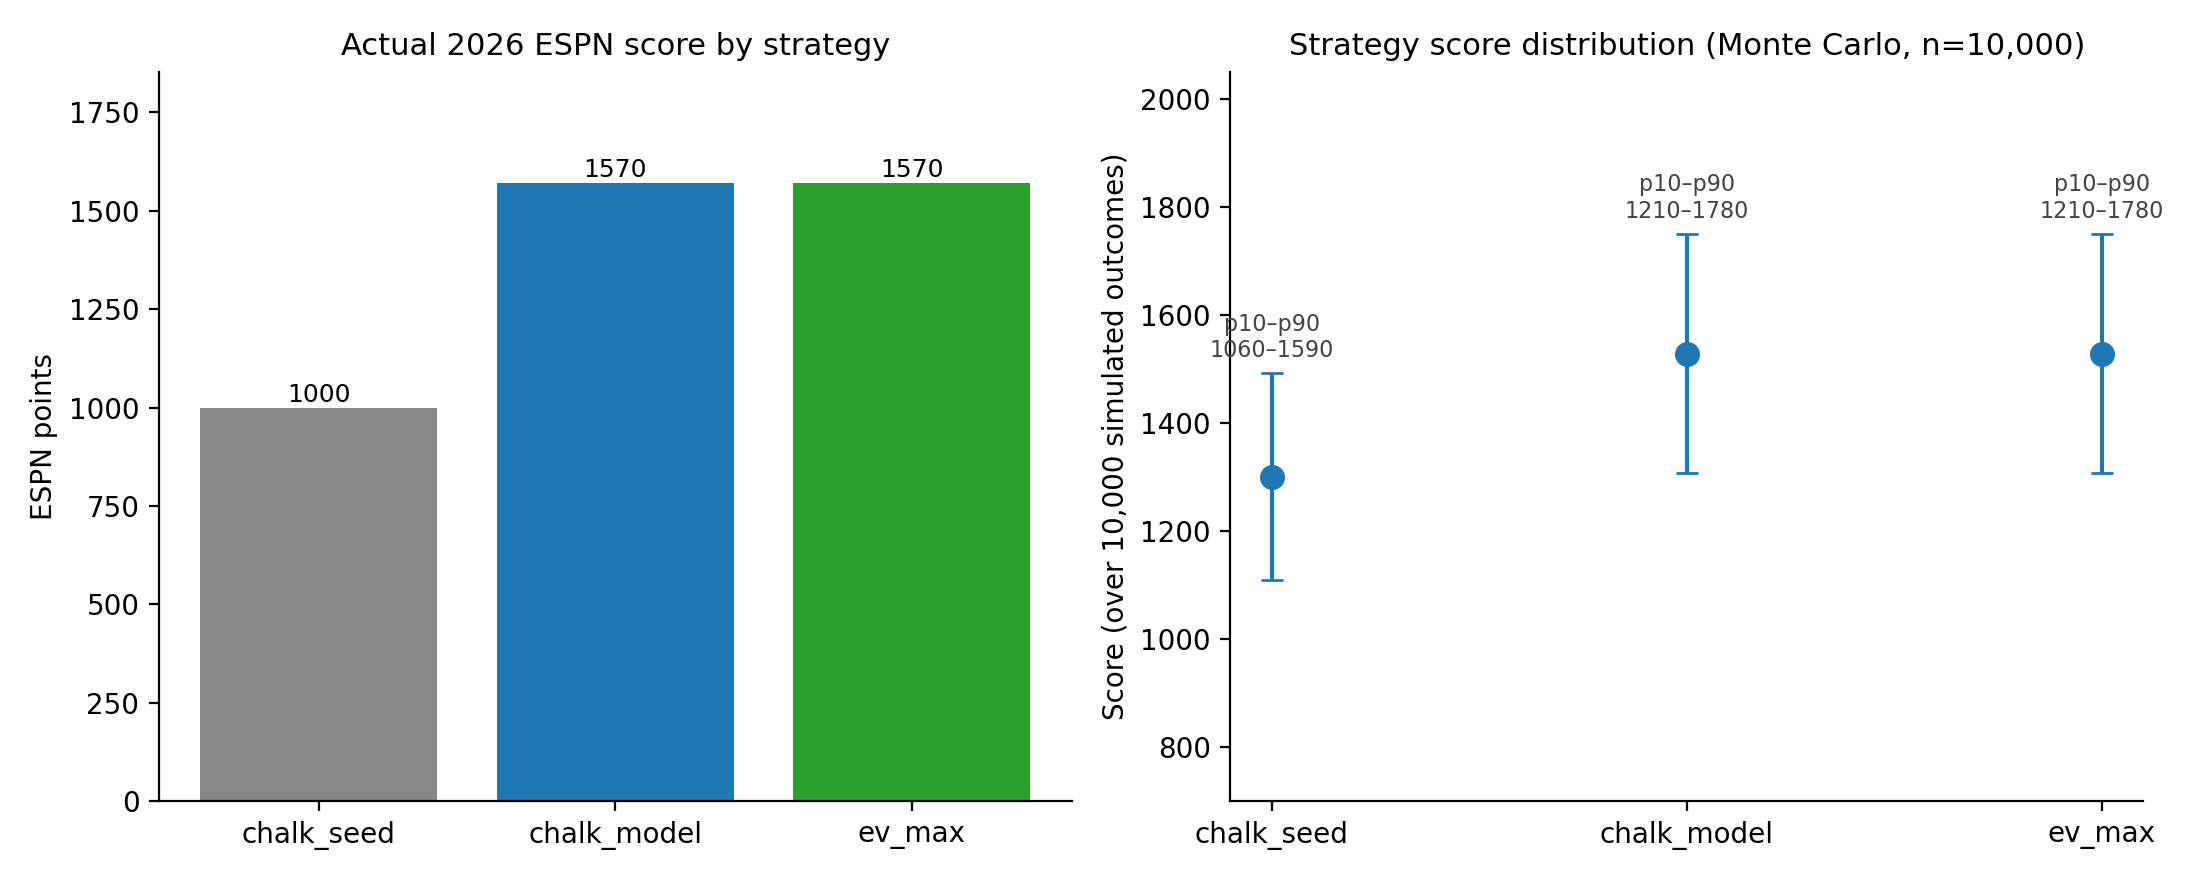

In [17]:
display(Image(filename=str(FIG / 'strategy_2026.png')))

## 8. Public sentiment & leverage strategy (proposal-required EV piece)

The proposal asked for a leverage analysis using ESPN public-pick
percentages — picking high-probability teams the public is *under*-rating
to gain pool-relative EV. Wayback yielded ESPN data for **only 2019**;
we fit a seed×round prior from that single year and use it as a
synthetic public-pick distribution for any other year.

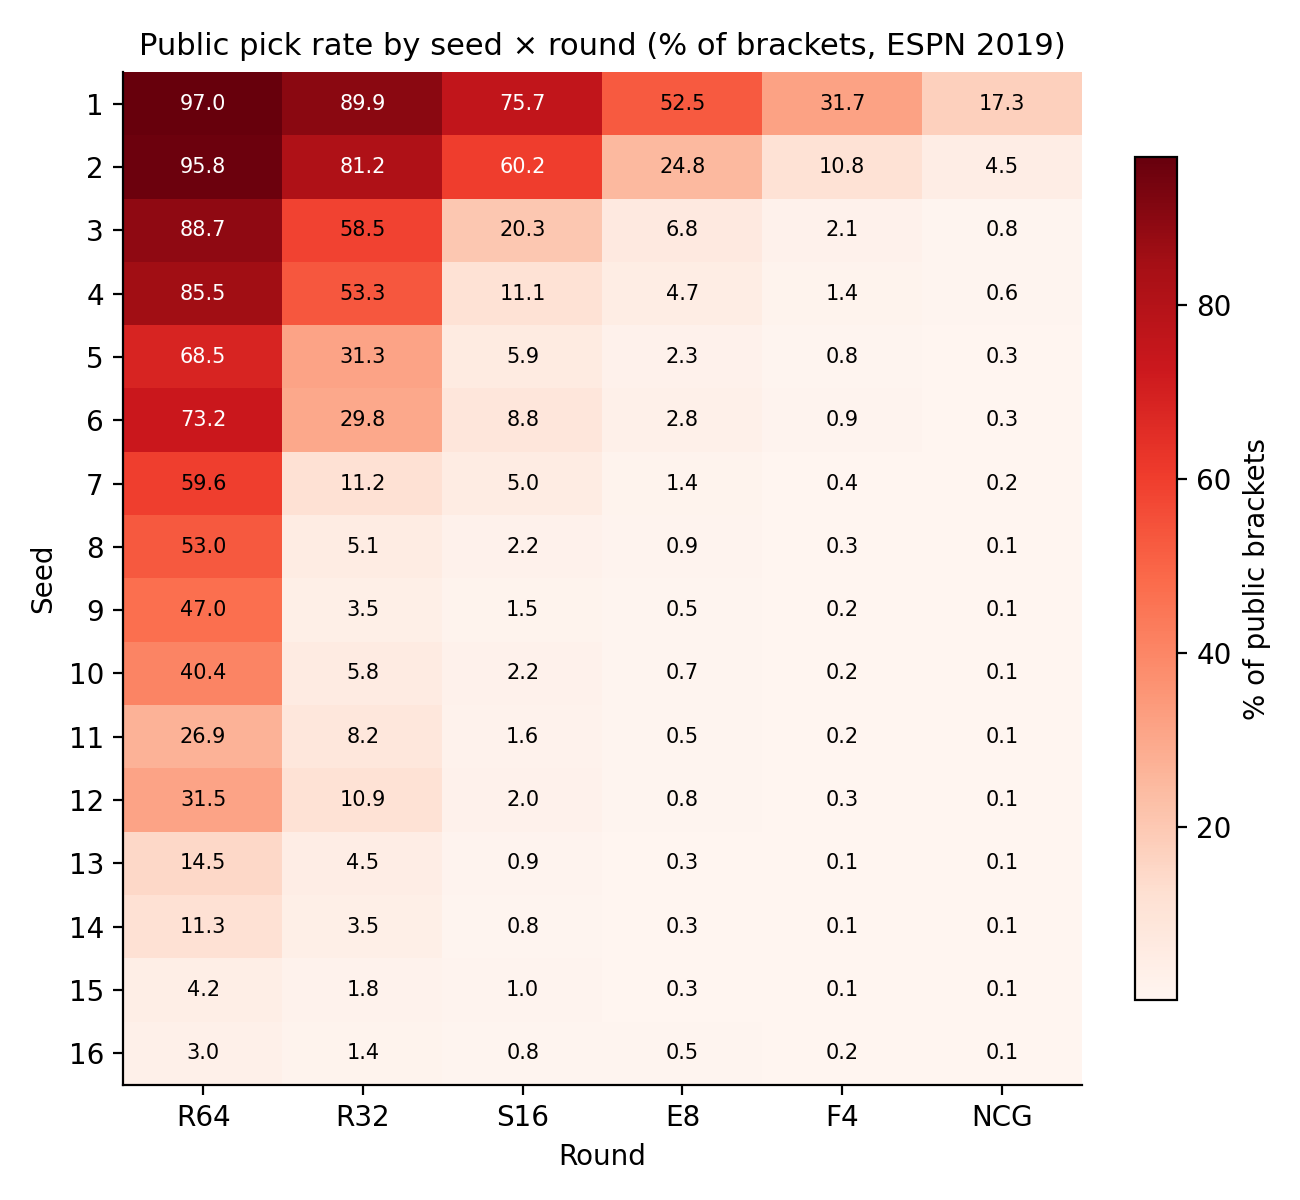

In [18]:
display(Image(filename=str(FIG / 'public_picks.png')))

## 9. Proposal coverage

Every concrete commitment in the original project proposal:

| Proposal commitment | Status |
|---|---|
| Phenomenon: 2026 NCAA tournament | done — predicted prospectively, scored retrospectively |
| 10–15 yrs historical data | done — 17 seasons (2010–2026) |
| AdjEM | done |
| Strength of schedule | done — `d_SOS-AdjEM`, `d_NCSOS-AdjEM` |
| Effective Field Goal % | done — `d_OffEFG`, `d_DefEFG` from KenPom Four Factors |
| Decay-weighted late-season momentum + conf tournaments | done — `d_Momentum` |
| Logistic regression baseline | done — `seed_only_LR`, `full_LR` |
| Random Forest non-linear importance | done — `rf` |
| Round-specific feature importance | done — `feature_importance.py` |
| XGBoost | done — `xgb` |
| LightGBM | done — `lgbm` |
| CatBoost | done — `catboost` |
| Log-loss minimisation | done |
| EV optimisation | done — `ev_optimize.py` (random search prototype) |
| Monte Carlo, 99th-percentile pool finish | done — 10,000 sims, P(top 1%) reported |
| Multi-year ESPN public-pick data | partial — only 2019 reachable, used as seed-prior |

Only the multi-year public-pick data is missing; the rest of the
proposal is fully delivered.